# DeepFool Adversarial Attacks

## DeepFool - Implementazione e Valutazione

Questo notebook implementa attacchi DeepFool da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")


Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione DeepFool (da zero)

DeepFool cerca la perturbazione piu piccola possibile per cambiare la predizione del modello
1. Calcola la classe inizialmente predetta
2. Stima la distanza dai confini delle altre classi usando punteggi e gradienti
3. Individua il confine piu vicino
4. Sposta leggermente l'immagine verso quel confine
5. Ripete finche la predizione cambia o viene raggiunto il numero massimo di iterazioni
6. Applica un piccolo overshoot per assicurarsi di superare il confine

In [2]:
def deepfool_attack(model, images, num_classes, overshoot, max_iter):
    """
    Esegue un attacco DeepFool su un batch di immagini.

    Args:
        model: modello target
        images: batch di immagini nel range [0, 1]
        num_classes: numero di classi
        overshoot: piccolo valore per superare il confine
        max_iter: numero massimo di iterazioni

    Returns:
        adv_images: immagini adversarial
        perturbation: perturbazione realmente applicata
    """

    adv_images = images.clone().detach()

    theoretical_perturbations = torch.zeros_like(images)
                                                 
    # DeepFool lavora separatamente su ogni immagine
    for image_id in range(images.size(0)):
        original_image = images[image_id:image_id+1].clone().detach()

        # classe predetta inizialmente dal modello
        with torch.no_grad():
            outputs = model(NORMALIZE(original_image))
            pred_original = torch.argmax(outputs, dim=1).item()

        total_perturbation = torch.zeros_like(original_image)

        for _ in range(max_iter):
            current_image = original_image + total_perturbation

            current_image = torch.clamp(current_image, 0, 1).detach()

            current_image.requires_grad_(True)

            outputs = model(NORMALIZE(current_image))
            pred_current = torch.argmax(outputs, dim=1).item()

            # termina quando la predizione cambia
            if pred_current != pred_original:
                break

            # gradienti dei punteggi di tutte le classi
            gradients = []

            for class_id in range(num_classes):
                
                # cancello i gradienti precedenti
                model.zero_grad()
                if current_image.grad is not None:
                    current_image.grad.zero_()

                outputs[0, class_id].backward(retain_graph=True)

                gradients.append(current_image.grad.clone().detach())

            original_gradient = gradients[pred_original]
            original_score = outputs[0, pred_original].detach()

            # cerco il confine
            min_distance = float('inf')
            best_step = torch.zeros_like(original_image)

            for class_id in range(num_classes):
                if class_id == pred_original:
                    continue

                gradient_difference = (gradients[class_id] - original_gradient)

                score_difference = (outputs[0, class_id].detach() - original_score)

                gradient_norm = gradient_difference.norm()

                if gradient_norm.item() == 0:
                    continue

                distance = (torch.abs(score_difference) / gradient_norm)

                if distance.item() < min_distance:
                    min_distance = distance.item()

                    best_step = (torch.abs(score_difference) / gradient_norm.pow(2)) * gradient_difference

            total_perturbation = total_perturbation + best_step

        perturbation_theoretical = (1 + overshoot) * total_perturbation

        adv_image = torch.clamp(original_image + perturbation_theoretical, 0, 1).detach()
        
        adv_images[image_id:image_id+1] = adv_image
        
        theoretical_perturbations[image_id:image_id+1] = perturbation_theoretical.detach()


    perturbation = adv_images - images
    
    return adv_images, perturbation.detach(), theoretical_perturbations.detach()

print("Funzione DeepFool implementata")

Funzione DeepFool implementata


## 3. Test DeepFool 

Test dell'attacco DeepFool con parametri standard

Metriche:
- **Accuracy clean**: % di immagini originali classificate correttamente
- **Accuracy adversarial**: % di immagini perturbate ancora classificate correttamente
- **Accuracy drop**: differenza tra accuracy clean e adversarial
- **Attack Success Rate (ASR)**: % di immagini inizialmente corrette che vengono classificate male dopo l'attacco
- **Norma L2 media su tutte le immagini**: grandezza media delle perturbazioni sull'intero test set
- **Norma L2 media sulle immagini clean corrette**: grandezza media delle perturbazioni sulle immagini inizialmente classificate correttamente
- **Norma L2 media sugli attacchi riusciti**: grandezza media delle perturbazioni che hanno effettivamente ingannato il modello (quella che mi serve)
- **Time**: tempo necessario per applicare l'attacco al test set

In [3]:
overshoot = 0.02
max_iter = 50

examples_store = {
    'success': [],
    'failure': []
}

correct_original = 0
correct_adv = 0
clean_correct_count = 0
attack_success_count = 0
total_samples = 0

total_l2_all = 0
total_l2_clean_correct = 0
total_l2_successful = 0

start_time = time.time()

model.eval()

print(f"\nTest DeepFool: overshoot={overshoot}, max_iter={max_iter}")

for images, labels in tqdm(test_loader, desc="DeepFool"):
    images = images.to(device)
    labels = labels.to(device)

    # predizioni su immagini originali
    with torch.no_grad():
        outputs_original = model(NORMALIZE(images))
        preds_original = torch.argmax(outputs_original, dim=1)

    # ATTACCO DEEPFOOL
    adv_images, perturbation, theoretical_perturbations = deepfool_attack(
        model,
        images.clone().detach(),
        N_CLASSES,
        overshoot,
        max_iter
    )

    # predizioni su immagini adversarial
    with torch.no_grad():
        outputs_adv = model(NORMALIZE(adv_images))
        preds_adv = torch.argmax(outputs_adv, dim=1)

    # immagini classificate correttamente prima dell'attacco
    clean_correct = preds_original == labels

    # immagini corrette prima e sbagliate dopo l'attacco
    success = clean_correct & (preds_adv != labels)

    correct_original += clean_correct.sum().item()
    correct_adv += (preds_adv == labels).sum().item()
    clean_correct_count += clean_correct.sum().item()
    attack_success_count += success.sum().item()
    total_samples += labels.size(0)

    # norma L2 di ogni perturbazione
    l2_norms = perturbation.reshape( perturbation.size(0), -1).norm(p=2, dim=1)

    # L2 su tutte le immagini
    total_l2_all += l2_norms.sum().item()

    # L2 sulle immagini inizialmente corrette
    total_l2_clean_correct += (l2_norms[clean_correct].sum().item())

    # L2 sugli attacchi riusciti
    total_l2_successful += (l2_norms[success].sum().item())

    # esempi per il plot
    for i in range(images.size(0)):
        pred_original = preds_original[i].item()
        pred_adv = preds_adv[i].item()
        true_label = labels[i].item()

        attack_success = (pred_original == true_label and pred_adv != true_label)

        attack_failure = (pred_original == true_label and pred_adv == true_label)

        example = {
            'image': images[i:i+1].detach().cpu().clone(),
            'adv_image': adv_images[i:i+1].detach().cpu().clone(),
            'perturbation_theoretical': theoretical_perturbations[i:i+1].detach().cpu().clone(),
            'perturbation': perturbation[i:i+1].detach().cpu().clone(),
            'pred_original': pred_original,
            'pred_adv': pred_adv,
            'true_label': true_label,
            'l2_norm': l2_norms[i].item()
        }

        if attack_success:
            examples_store['success'].append(example)

        elif attack_failure:
            examples_store['failure'].append(example)

# metriche
accuracy = correct_original / total_samples
accuracy_adv = correct_adv / total_samples
accuracy_drop = accuracy - accuracy_adv
asr = attack_success_count / clean_correct_count

mean_l2_all = total_l2_all / total_samples
mean_l2_clean_correct = (total_l2_clean_correct / clean_correct_count)
mean_l2_successful = (total_l2_successful / attack_success_count)

elapsed_time = time.time() - start_time

df_results = {
    'overshoot': overshoot,
    'max_iter': max_iter,
    'accuracy': accuracy,
    'accuracy_adv': accuracy_adv,
    'accuracy_drop': accuracy_drop,
    'asr': asr,
    'mean_l2_all': mean_l2_all,
    'mean_l2_clean_correct': mean_l2_clean_correct,
    'mean_l2_successful': mean_l2_successful,
    'time': elapsed_time
}

print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
print(f"  L2 media su tutte le immagini: {mean_l2_all:.4f}")
print(f"  L2 media sulle immagini clean corrette: {mean_l2_clean_correct:.4f}")
print(f"  L2 media sugli attacchi riusciti: {mean_l2_successful:.4f}")
print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest DeepFool completato")


Test DeepFool: overshoot=0.02, max_iter=50


DeepFool: 100%|██████████| 32/32 [00:36<00:00,  1.15s/it]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0752 (7.52%)
  Accuracy Drop: 0.8367 (83.67%)
  Attack Success Rate: 0.9692 (96.92%)
  L2 media su tutte le immagini: 0.4063
  L2 media sulle immagini clean corrette: 0.4366
  L2 media sugli attacchi riusciti: 0.4450
  Tempo: 36.75s

Test DeepFool completato


## 4. Plot delle immagini perturbate

- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

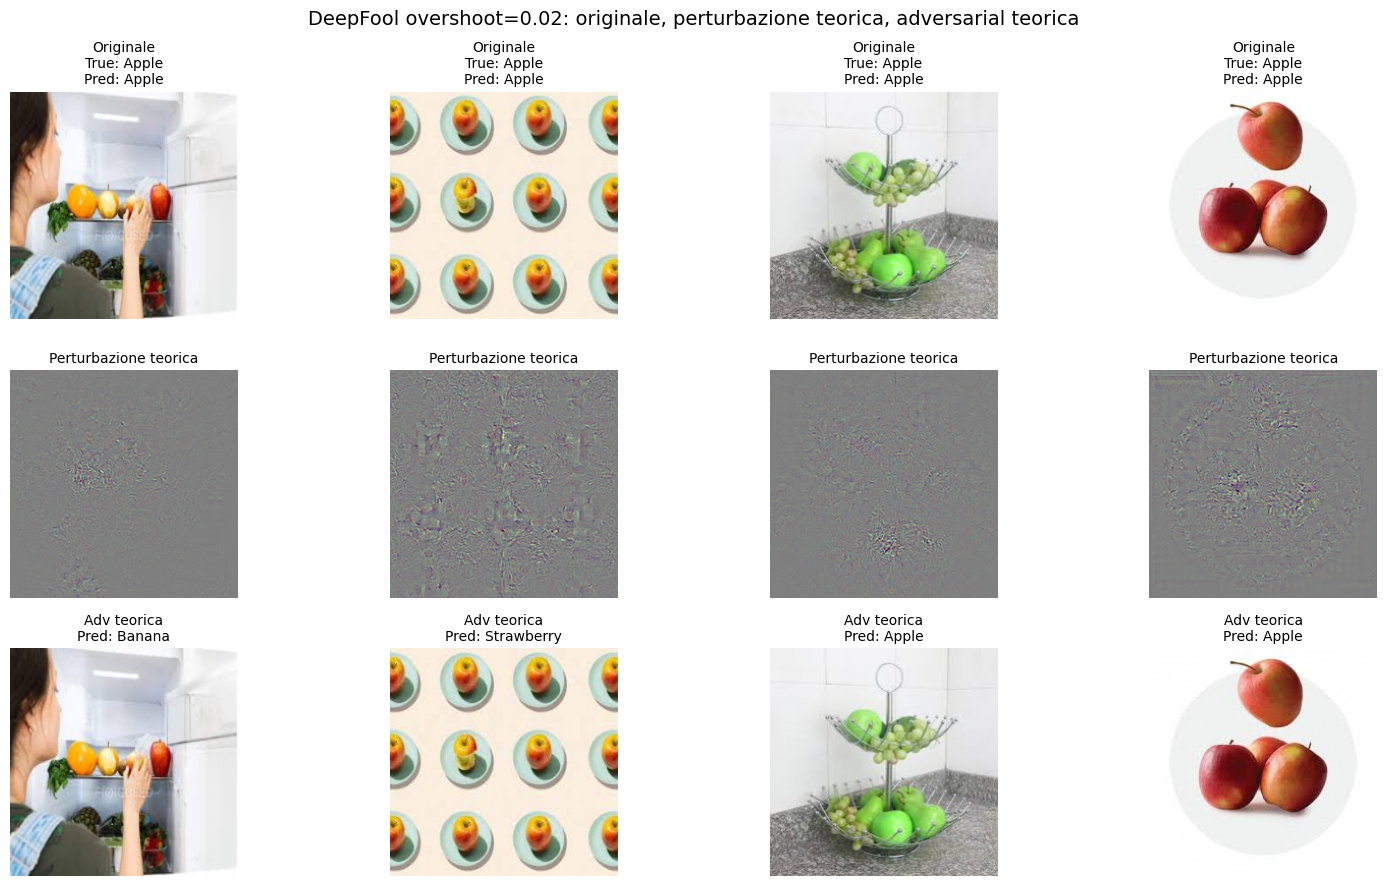

In [4]:
# scelta arbitraria di 4 esempi (2 successi e 2 fallimenti)
selected_examples = (
    examples_store['success'][:2] +
    examples_store['failure'][:2]
)

fig, axes = plt.subplots(
    3,
    len(selected_examples),
    figsize=(4 * len(selected_examples), 9)
)

for img_idx, example in enumerate(selected_examples):

    img_original = example['image'][0].numpy()
    img_original = np.transpose(img_original, (1, 2, 0))
    img_original = np.clip(img_original, 0, 1)

    perturbation_theoretical = example['perturbation_theoretical'][0].numpy()
    perturbation_theoretical = np.transpose(
        perturbation_theoretical,
        (1, 2, 0)
    )

    # visualizzazione della perturbazione:
    # valori negativi -> scuro
    # zero -> grigio
    # valori positivi -> chiaro
    abs_max = np.max(np.abs(perturbation_theoretical))

    perturbation_plot = perturbation_theoretical / (2 * abs_max + 1e-8)
    perturbation_plot = perturbation_plot + 0.5
    perturbation_plot = np.clip(perturbation_plot, 0, 1)

    img_adv_theoretical = img_original + perturbation_theoretical
    img_adv_theoretical = np.clip(img_adv_theoretical, 0, 1)

    axes[0, img_idx].imshow(img_original)
    axes[0, img_idx].set_title(
        f"Originale\nTrue: {class_names[example['true_label']]}\n"
        f"Pred: {class_names[example['pred_original']]}",
        fontsize=10
    )
    axes[0, img_idx].axis('off')

    axes[1, img_idx].imshow(perturbation_plot)
    axes[1, img_idx].set_title(
        "Perturbazione teorica",
        fontsize=10
    )
    axes[1, img_idx].axis('off')

    axes[2, img_idx].imshow(img_adv_theoretical)
    axes[2, img_idx].set_title(
        f"Adv teorica\nPred: {class_names[example['pred_adv']]}",
        fontsize=10
    )
    axes[2, img_idx].axis('off')

plt.suptitle(
    f"DeepFool overshoot={overshoot}: originale, perturbazione teorica, adversarial teorica",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    results_path / "deepfool_examples_theoretical.png",
    dpi=120,
    bbox_inches='tight'
)

plt.show()

## 5. Plot delle Metriche

Generazione di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Norma L2 media su tutte le immagini
- Norma L2 media sulle immagini clean classificate correttamente
- Norma L2 media sugli attacchi riusciti
- Tempo per applicare l'attacco al test set

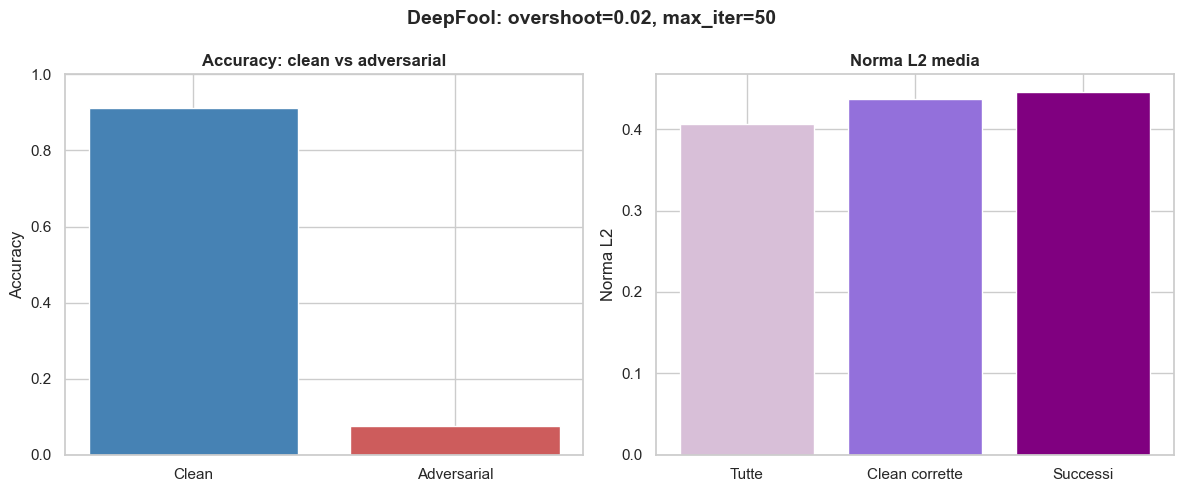

Accuracy Drop: 0.8367 (83.67%)
Attack Success Rate: 0.9692 (96.92%)
Tempo: 36.75s


In [5]:
accuracy = df_results['accuracy']
accuracy_adv = df_results['accuracy_adv']
accuracy_drop = df_results['accuracy_drop']
asr = df_results['asr']

mean_l2_all = df_results['mean_l2_all']
mean_l2_clean_correct = df_results['mean_l2_clean_correct']
mean_l2_successful = df_results['mean_l2_successful']

elapsed_time = df_results['time']

sns.set(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# accuracy clean vs adversarial
ax = axes[0]
ax.bar(
    ['Clean', 'Adversarial'],
    [accuracy, accuracy_adv],
    color=['steelblue', 'indianred']
)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: clean vs adversarial', fontweight='bold')

# norme L2 medie
ax = axes[1]
ax.bar(
    ['Tutte', 'Clean corrette', 'Successi'],
    [mean_l2_all, mean_l2_clean_correct, mean_l2_successful],
    color=['thistle', 'mediumpurple', 'purple']
)
ax.set_ylabel('Norma L2')
ax.set_title('Norma L2 media', fontweight='bold')

plt.suptitle(
    f"DeepFool: overshoot={overshoot}, max_iter={max_iter}",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    results_path / 'DF_metrics_summary.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print(f"Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
print(f"Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
print(f"Tempo: {elapsed_time:.2f}s")

summary_df = pd.DataFrame({
    'overshoot': [overshoot],
    'max_iter': [max_iter],
    'accuracy': [accuracy],
    'accuracy_adv': [accuracy_adv],
    'accuracy_drop': [accuracy_drop],
    'asr': [asr],
    'mean_l2_all': [mean_l2_all],
    'mean_l2_clean_correct': [mean_l2_clean_correct],
    'mean_l2_successful': [mean_l2_successful],
    'time_s': [elapsed_time]
})

summary_df.to_csv(
    results_path / 'DF_metrics_summary.csv',
    index=False
)

## 6.1. Adversarial Training

Addestramento di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (DeepFool con overshoot=0.02, max_iter_training=5)

In [6]:
overshoot_adv_training = 0.02
max_iter_adv_training = 5

model_path = ROOT / "models" / "best_resnet18.pt"

adv_loss_fn = nn.CrossEntropyLoss()

num_epochs = 30
patience = 10
best_val_loss = float('inf')
patience_counter = 0

adv_train_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

model_save_path = ROOT / "models" / "best_df_0.02.pt"

df_model = models.resnet18(pretrained=True)
df_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
df_model = df_model.to(device)
df_model.load_state_dict(torch.load(model_path))

adv_optimizer = torch.optim.Adam(df_model.parameters(), lr=0.0001)

print(f"\nAdversarial training DeepFool con overshoot={overshoot_adv_training}, max_iter={max_iter_adv_training}")

for epoch in range(num_epochs):
    df_model.train()

    epoch_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    ):
        images = images.to(device)
        labels = labels.to(device)

        batch_size_half = images.size(0) // 2

        clean_images = images[:batch_size_half]

        df_model.eval()

        adv_images, perturbation, theoretical_perturbations = deepfool_attack(
            df_model,
            images[batch_size_half:].clone().detach(),
            N_CLASSES,
            overshoot_adv_training,
            max_iter_adv_training
        )

        df_model.train()

        mixed_images = torch.cat([clean_images, adv_images], dim=0)
        mixed_labels = labels

        adv_optimizer.zero_grad()

        outputs = df_model(NORMALIZE(mixed_images))
        loss = adv_loss_fn(outputs, mixed_labels)

        loss.backward()
        adv_optimizer.step()

        epoch_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == mixed_labels).sum().item()
        total_train += mixed_labels.size(0)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct_train / total_train

    # validazione su immagini pulite
    df_model.eval()

    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = df_model(NORMALIZE(images))
            loss = adv_loss_fn(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    adv_train_history['train_loss'].append(train_loss)
    adv_train_history['train_acc'].append(train_acc)
    adv_train_history['val_loss'].append(val_loss)
    adv_train_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(df_model.state_dict(), model_save_path)
        print("Nuovo migliore modello salvato")

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("\nAdversarial training DeepFool completato")
print(f"Miglior validation loss: {best_val_loss:.4f}")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Adversarial training DeepFool con overshoot=0.02, max_iter=5


Epoch 1/30:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/30: 100%|██████████| 250/250 [02:05<00:00,  1.99it/s]


Epoch 1: Train Loss=0.5597, Train Acc=0.7397, Val Loss=0.3614, Val Acc=0.8717
Nuovo migliore modello salvato


...

Epoch 9: Train Loss=0.4646, Train Acc=0.7503, Val Loss=0.5878, Val Acc=0.8056


Epoch 10/30: 100%|██████████| 250/250 [02:10<00:00,  1.91it/s]


Epoch 10: Train Loss=0.4386, Train Acc=0.7556, Val Loss=0.5963, Val Acc=0.7926


Epoch 11/30: 100%|██████████| 250/250 [02:11<00:00,  1.90it/s]


Epoch 11: Train Loss=0.4458, Train Acc=0.7521, Val Loss=0.5996, Val Acc=0.7986
Early stopping at epoch 11

Adversarial training DeepFool completato
Miglior validation loss: 0.3614


## 6.2. Adversarial Training

Addestramento di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (DeepFool con overshoot=0.02, max_iter_training=50)

In [7]:
df_iter50_history = pd.read_csv(results_path / "train_deepfool_iter50_history.csv")

print(df_iter50_history.to_string(index=False))

df_model = models.resnet18(pretrained=False)

df_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)

df_model = df_model.to(device)

model_save_path = ROOT / "models" / "best_df_0.02_iter50.pt"

df_model.load_state_dict(torch.load(model_save_path, map_location=device))

df_model.eval()

print("Modello DeepFool 50 iterazioni caricato")
print((ROOT / "models" / "best_df_0.02_iter50.pt").exists())
print((results_path / "train_deepfool_iter50_history.csv").exists())

 train_loss  train_acc  val_loss  val_acc
   0.552023   0.747494  0.436460 0.840681
   0.575691   0.713534  0.441293 0.851703
   0.561124   0.709524  0.449136 0.833667
   0.542948   0.715288  0.515649 0.812625
   0.506030   0.736717  0.470890 0.832665
   0.490193   0.736466  0.499160 0.823647
   0.484870   0.737970  0.552653 0.803607
   0.461423   0.743484  0.519128 0.819639
   0.459976   0.746241  0.610406 0.785571
   0.450147   0.747118  0.587623 0.791583
   0.442372   0.755388  0.602187 0.798597
Modello DeepFool 50 iterazioni caricato
True
True


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## 7. Confronto: Modello Originale vs Modello DeepFool

Confronto del modello originale con il modello addestrato avversarialmente
Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR
- norma L2 media su tutte le immagini
- norma L2 media sulle immagini clean classificate correttamente
- norma L2 media sugli attacchi riusciti (piu importante)


Confronto DeepFool con overshoot=0.02, max_iter=50


Confronto DeepFool: 100%|██████████| 32/32 [01:13<00:00,  2.30s/it]


                        model  overshoot_training  overshoot_attack  accuracy_clean  accuracy_adversarial  accuracy_drop     asr  mean_l2_all  mean_l2_clean_correct  mean_l2_successful
                    Originale                 NaN              0.02        0.911824               0.07515       0.836673 0.97033     0.406258               0.436607            0.444507
Adversarial Training DeepFool                0.02              0.02        0.898798               0.07515       0.823647 1.00000     3.541786               3.855450            3.855450


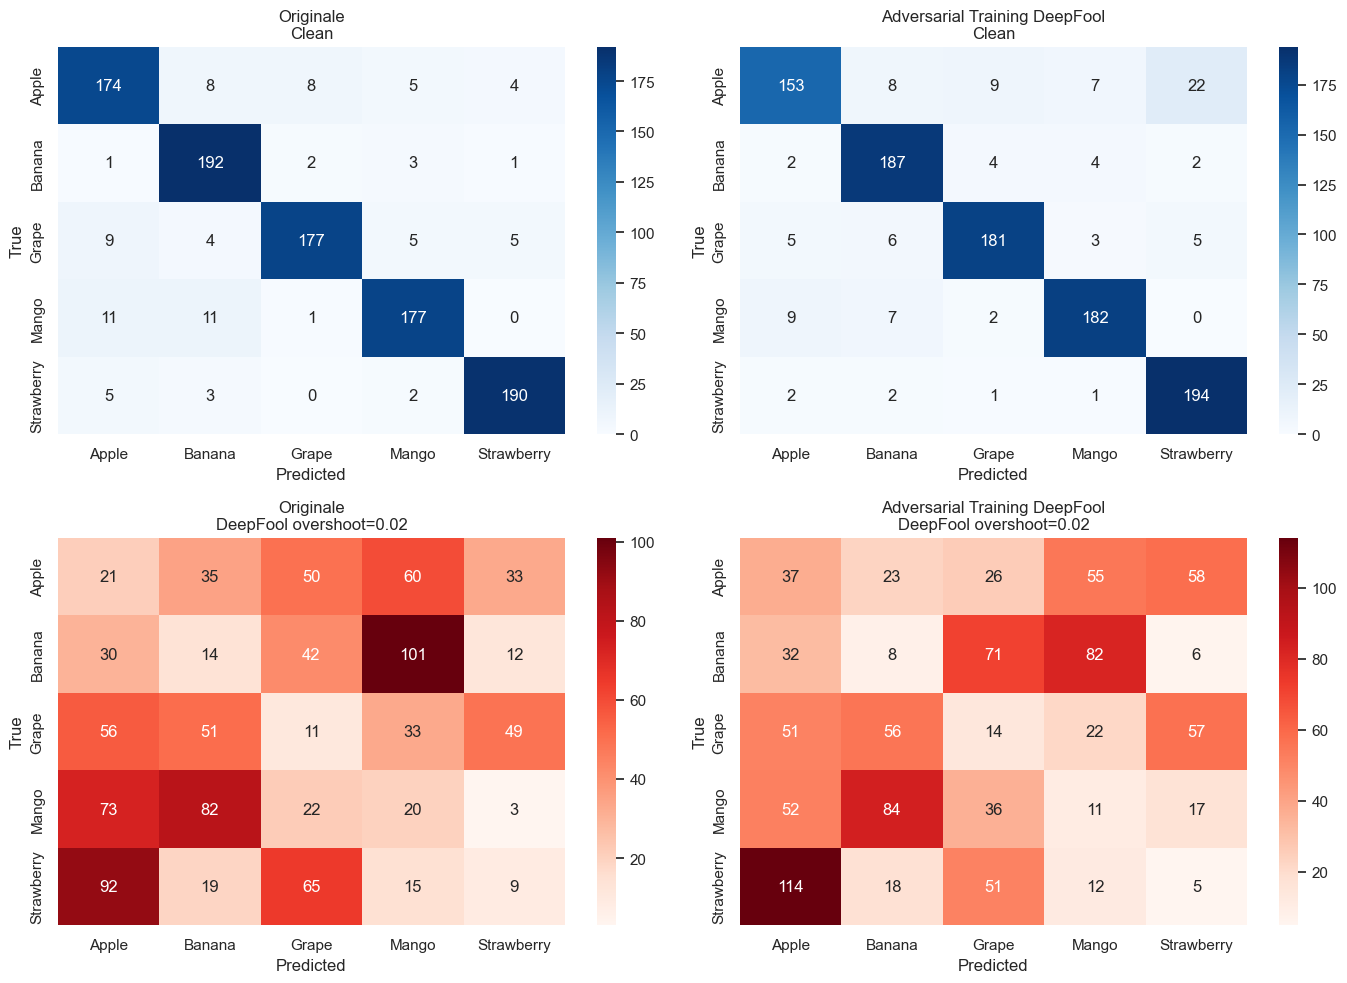

In [8]:
overshoot_test = 0.02
max_iter = 50

df_model = models.resnet18(pretrained=False)
df_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
df_model = df_model.to(device)

model_save_path = ROOT / "models" / "best_df_0.02.pt"
df_model.load_state_dict(torch.load(model_save_path, map_location=device))

model.eval()
df_model.eval()

# modelli da confrontare
comparison_models = {
    'Originale': {
        'model': model,
        'overshoot_training': None
    },
    'Adversarial Training DeepFool': {
        'model': df_model,
        'overshoot_training': overshoot_adv_training
    }
}

comparison_stats = {}

for model_name in comparison_models:
    comparison_stats[model_name] = {
        'correct_clean': 0,
        'correct_adv': 0,
        'attack_success': 0,
        'total_l2_all': 0,
        'total_l2_clean_correct': 0,
        'total_l2_successful': 0,
        'preds_clean': [],
        'preds_adv': []
    }

total = 0
all_labels = []

print(f"\nConfronto DeepFool con overshoot={overshoot_test}, max_iter={max_iter}")

for images, labels in tqdm(test_loader, desc="Confronto DeepFool"):
    images = images.to(device)
    labels = labels.to(device)

    all_labels.extend(labels.cpu().numpy())
    total += labels.size(0)

    for model_name, model_info in comparison_models.items():
        current_model = model_info['model']

        # immagini pulite
        with torch.no_grad():
            outputs_clean = current_model(NORMALIZE(images))
            preds_clean = torch.argmax(outputs_clean, dim=1)

        # immagini perturbate
        adv_images, perturbation, theoretical_perturbations = deepfool_attack(
            current_model,
            images.clone().detach(),
            N_CLASSES,
            overshoot_test,
            max_iter
        )

        with torch.no_grad():
            outputs_adv = current_model(NORMALIZE(adv_images))
            preds_adv = torch.argmax(outputs_adv, dim=1)

        clean_correct = preds_clean == labels
        success = clean_correct & (preds_adv != labels)

        comparison_stats[model_name]['correct_clean'] += clean_correct.sum().item()
        
        comparison_stats[model_name]['correct_adv'] += (preds_adv == labels).sum().item()
        
        comparison_stats[model_name]['attack_success'] += success.sum().item()

        l2_norms = perturbation.reshape(perturbation.size(0), -1).norm(p=2, dim=1)

        # tutte
        comparison_stats[model_name]['total_l2_all'] += l2_norms.sum().item()

        # clean corrette
        comparison_stats[model_name]['total_l2_clean_correct'] += (l2_norms[clean_correct].sum().item())

        # attacchi riusciti
        comparison_stats[model_name]['total_l2_successful'] += (l2_norms[success].sum().item())

        comparison_stats[model_name]['preds_clean'].extend(preds_clean.cpu().numpy())

        comparison_stats[model_name]['preds_adv'].extend(preds_adv.cpu().numpy())

# metriche
comparison_results = []

for model_name, model_info in comparison_models.items():
    stats = comparison_stats[model_name]

    accuracy_clean = stats['correct_clean'] / total
    accuracy_adv = stats['correct_adv'] / total
    accuracy_drop = accuracy_clean - accuracy_adv
    asr = stats['attack_success'] / stats['correct_clean']
    mean_l2_all = stats['total_l2_all'] / total
    mean_l2_clean_correct = (stats['total_l2_clean_correct'] / stats['correct_clean'])
    mean_l2_successful = (stats['total_l2_successful'] / stats['attack_success'])

    comparison_results.append({
        'model': model_name,
        'overshoot_training': model_info['overshoot_training'],
        'overshoot_attack': overshoot_test,
        'accuracy_clean': accuracy_clean,
        'accuracy_adversarial': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'mean_l2_all': mean_l2_all,
        'mean_l2_clean_correct': mean_l2_clean_correct,
        'mean_l2_successful': mean_l2_successful
    })

# tabella riassuntiva
comparison_df = pd.DataFrame(comparison_results)

print(comparison_df.to_string(index=False))

comparison_df.to_csv(
    results_path / "DF_original_vs_adv.csv",
    index=False
)

# cm
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for column, model_name in enumerate(comparison_models):
    stats = comparison_stats[model_name]

    cm_clean = confusion_matrix(
        all_labels,
        stats['preds_clean']
    )

    cm_adv = confusion_matrix(
        all_labels,
        stats['preds_adv']
    )

    sns.heatmap(
        cm_clean,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0, column]
    )

    axes[0, column].set_title(f'{model_name}\nClean')
    axes[0, column].set_xlabel('Predicted')
    axes[0, column].set_ylabel('True')

    sns.heatmap(
        cm_adv,
        annot=True,
        fmt='d',
        cmap='Reds',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1, column]
    )

    axes[1, column].set_title(
        f'{model_name}\nDeepFool overshoot={overshoot_test}'
    )
    axes[1, column].set_xlabel('Predicted')
    axes[1, column].set_ylabel('True')

plt.tight_layout()

plt.savefig(
    results_path / "DF_original_vs_adv.png",
    dpi=120,
    bbox_inches='tight'
)

plt.show()